# 03_matplotlib

Matplotlib란, 파이썬 시각화의 기본 라이브러리

> 작성 환경: matplotlib 3.11.2 / 한글 폰트는 koreanize_matplotlib 사용
> 데이터: 02번과 동일한 titanic.csv

In [1]:
%pip install -U setuptools koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


---

## 주요 특징
- 2차원 그래프에 특화
- pyplot 모듈을 통해 MATLAB 스타일로 그린다
- 선 그래프, 산점도, 히스토그램 등

## 구조 (Figure / Axes / Artist)

| 용어 | 뜻 | 비유 |
|---|---|---|
| **Figure** | 그래프가 그려지는 **페이지 전체** | 도화지 |
| **Axes** | 그 안의 **그래프 한 개** (축, 데이터, 제목 포함) | 도화지 위에 그린 그림 하나 |
| **Artist** | 선, 점, 텍스트, 범례 등 화면에 그려지는 **모든 요소** | 그림을 이루는 선 하나하나 |

- Figure 하나에 Axes가 여러 개 들어갈 수 있다 → 이게 subplot이다
- **Axes(그래프 한 개) ≠ Axis(축 하나).** 철자가 비슷해서 헷갈리는데 다른 개념이다

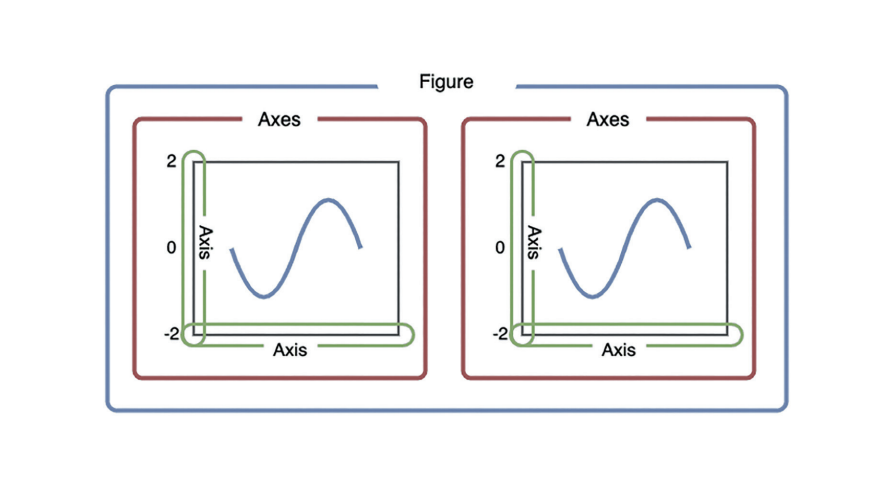

## 그래프 함수의 포맷 문자열
1. 색상
- r: 빨간색
- g: 초록색
- b: 파란색
- y: 노란색
- k: 검정색  
2. 마커 기호
- o: 원
- ^: 위쪽 삼각형
- v: 아래쪽 삼각형
- x: 엑스
- *: 별모양  
3. 선 스타일 기호
- ```-```: 실선(기본값)
- ```--```: 대시선
- ```:```: 점선

### 조합 규칙

색상 + 마커 + 선스타일을 **한 문자열로 붙여서** 쓴다. 순서는 상관없다.

| 문자열 | 의미 |
|---|---|
| `"r--"` | 빨간 대시선 |
| `"go"` | 초록 원 마커 (선 없음) |
| `"b^-"` | 파란 삼각형 마커 + 실선 |

- 마커만 쓰고 선 스타일을 안 쓰면 **점만 찍힌다**
- 길게 쓰려면 따로 지정: `plt.plot(X, y, color="red", marker="o", linestyle="--")`

---

## 기본 설정 함수

| 함수 | 역할 |
|---|---|
| `plt.title("제목")` | 그래프 제목 |
| `plt.xlabel("이름")` | x축 이름 |
| `plt.ylabel("이름")` | y축 이름 |
| `plt.legend()` | **범례.** 선을 여러 개 그릴 때 필수 |
| `plt.grid(True)` | 격자. 값을 눈으로 읽을 때 |
| `plt.figure(figsize=(8,5))` | 그림 크기 (가로, 세로 / 단위 인치) |
| `plt.xlim(0, 100)` | x축 범위 제한 |
| `plt.show()` | 그림을 화면에 출력 |

### legend는 label과 짝이다

`plt.legend()`는 **`label=`로 이름을 붙인 선만** 범례에 넣는다.
label 없이 legend()만 부르면 경고가 뜨고 아무것도 안 나온다.

### plt 방식 vs ax 방식 — 함수 이름이 다르다

| plt 방식 | ax 방식 (subplots에서 사용) |
|---|---|
| plt.title() | ax.set_title() |
| plt.xlabel() | ax.set_xlabel() |
| plt.xlim() | ax.set_xlim() |

ax 쪽은 앞에 **set_** 가 붙는다.

---

## 기본 차트 종류
- Line plot
- Scatter plot
- Histogram
- Bar plot
- Box plot
- Pie plot
- Heatmap (seaborn에서 다룸)

---

### 기본 세팅

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib   # 한글 폰트 자동 설정

# 기본 그림 크기 (기본값이 작아서 글자가 겹친다)
plt.rcParams['figure.figsize'] = (8, 5)

print(plt.matplotlib.__version__)

3.11.2


---
### 실습 데이터

문법은 난수로 익히고, **바로 아래에서 타이타닉 실데이터로 다시 그린다.**
난수는 문법을 보기엔 깔끔하지만 해석할 게 없기 때문이다.

In [3]:
df = pd.read_csv("titanic.csv")

# 02번에서 한 전처리 재적용
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"])

print(df.shape)
df.head(3)

(891, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


### Line plot
주로 시간의 흐름이나 순서에 따라 데이터가 어떻게 변하는지(추이/트렌드)를 볼 때 사용

- plot()을 여러 번 호출하면 하나의 그림에 여러 선을 겹쳐 그릴 수 있다
- 이때 label= 과 legend() 로 어느 선이 뭔지 표시한다

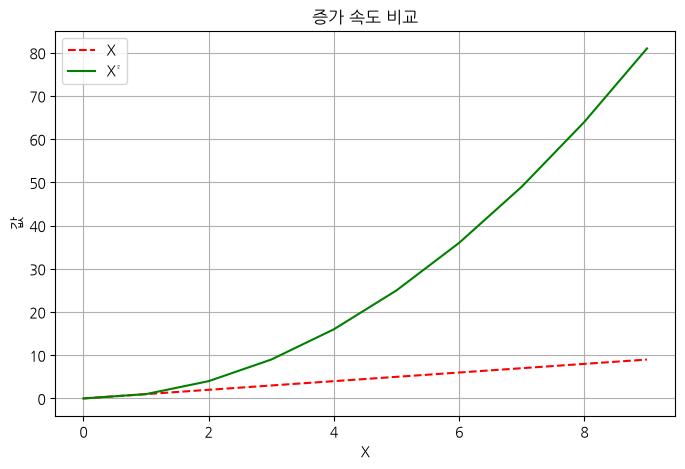

In [4]:
X = np.arange(10)

plt.plot(X, X,    "r--", label="X")
plt.plot(X, X**2, "g-",  label="X²")

plt.title("증가 속도 비교")
plt.xlabel("X")
plt.ylabel("값")
plt.legend()
plt.grid(True)
plt.show()

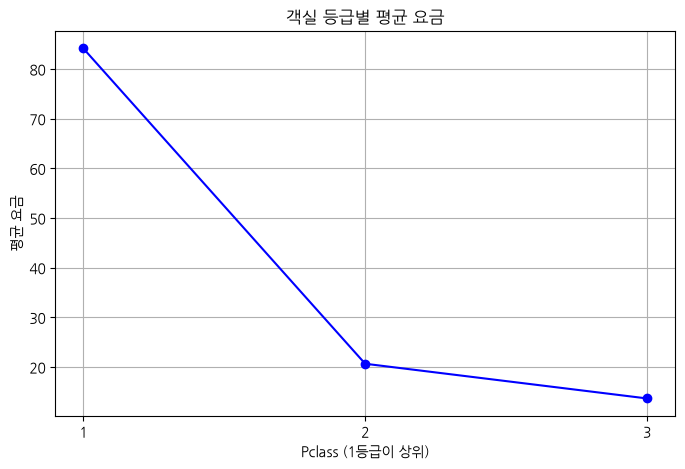

In [5]:
# 등급(Pclass)별 평균 요금
fare = df.groupby("Pclass")["Fare"].mean()

plt.plot(fare.index, fare.values, "bo-")
plt.title("객실 등급별 평균 요금")
plt.xlabel("Pclass (1등급이 상위)")
plt.ylabel("평균 요금")
plt.xticks([1, 2, 3])        # 1,2,3만 눈금으로 (기본은 1.5 같은 소수도 찍힌다)
plt.grid(True)
plt.show()

### Scatter plot
주로 두 수치형 변수 사이에서 어떤 상관관계가 있는지 파악할 때 사용

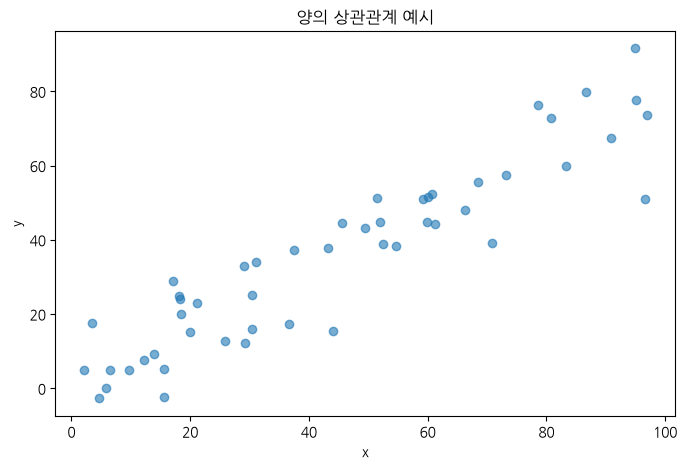

In [6]:
np.random.seed(42)   # 매번 같은 결과가 나오게 고정

n = 50
x = np.random.rand(n) * 100
y = x * 0.8 + np.random.randn(n) * 10   # x에 비례 + 약간의 잡음

plt.scatter(x, y, alpha=0.6)
plt.title("양의 상관관계 예시")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

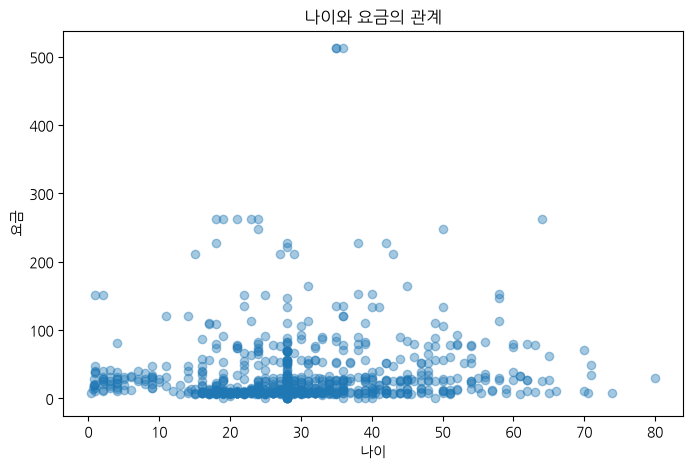

In [7]:
plt.scatter(df["Age"], df["Fare"], alpha=0.4)
plt.title("나이와 요금의 관계")
plt.xlabel("나이")
plt.ylabel("요금")
plt.show()

### Histogram
연속형 수치 데이터가 어디에 얼마나 몰려있는지 확인할 때 사용

**bins가 핵심 파라미터다.** 막대를 몇 칸으로 나눌지를 정한다(기본 10).
같은 데이터라도 bins를 바꾸면 그림이 완전히 달라진다.

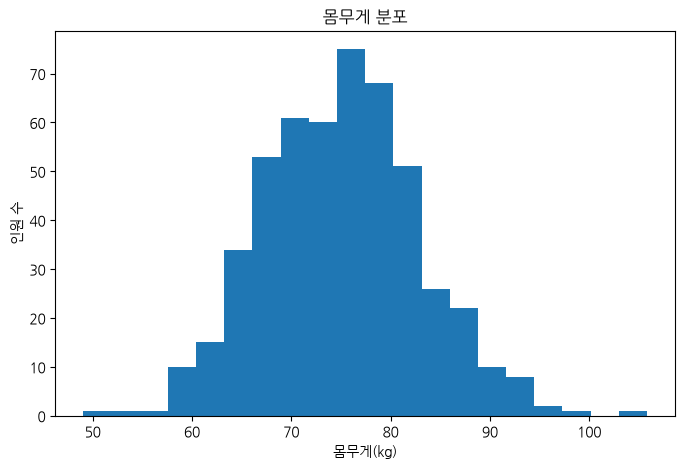

In [8]:
np.random.seed(42)
weight = np.random.normal(75, 8, 500)   # 평균 75, 표준편차 8, 500개

plt.hist(weight, bins=20)
plt.title("몸무게 분포")
plt.xlabel("몸무게(kg)")
plt.ylabel("인원 수")
plt.show()

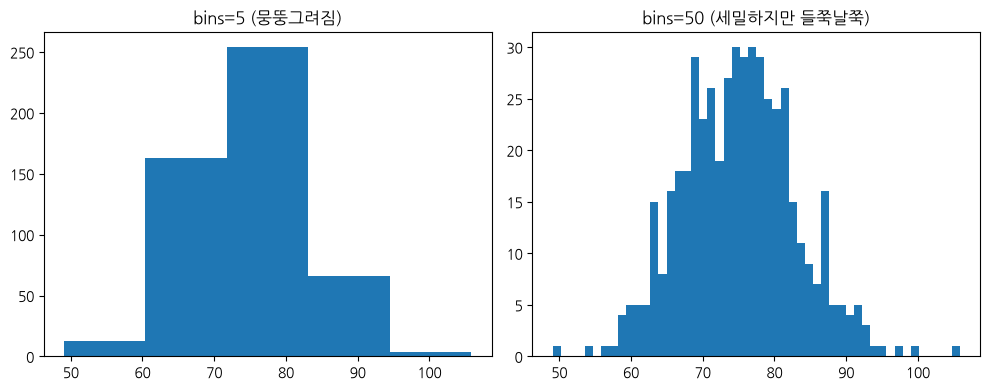

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(weight, bins=5)
ax[0].set_title("bins=5 (뭉뚱그려짐)")

ax[1].hist(weight, bins=50)
ax[1].set_title("bins=50 (세밀하지만 들쭉날쭉)")

plt.tight_layout()
plt.show()

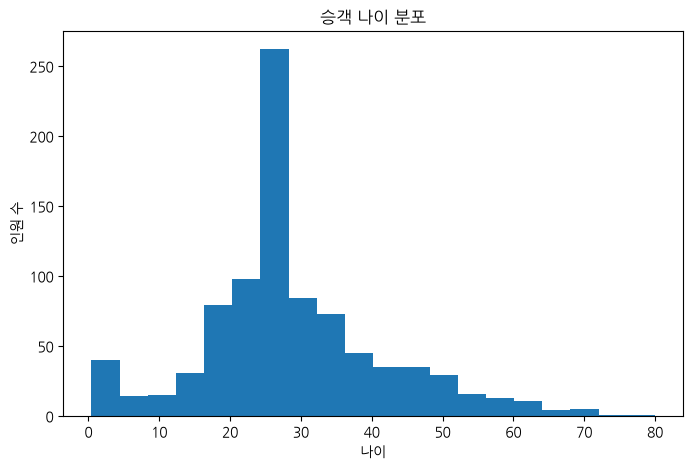

In [10]:
plt.hist(df["Age"], bins=20)
plt.title("승객 나이 분포")
plt.xlabel("나이")
plt.ylabel("인원 수")
plt.show()

### 여기서 읽어낸 것

28세 구간의 막대가 혼자 튀어 올라 있다.
02번에서 Age 결측치 177개를 **중앙값 28로 채웠기 때문**이다.

02번에서 글로만 적었던 "결측치를 채우는 처리는 뒤쪽 분석까지 오염시킨다"가
그림으로 드러나는 지점이다.
**시각화는 전처리가 제대로 됐는지 확인하는 수단이기도 하다.**

### Bar plot
범주형 데이터의 수치적 크기를 길이나 높이로 표현하여, 서로 다른 항목 간의 크기를 비교할 때 사용

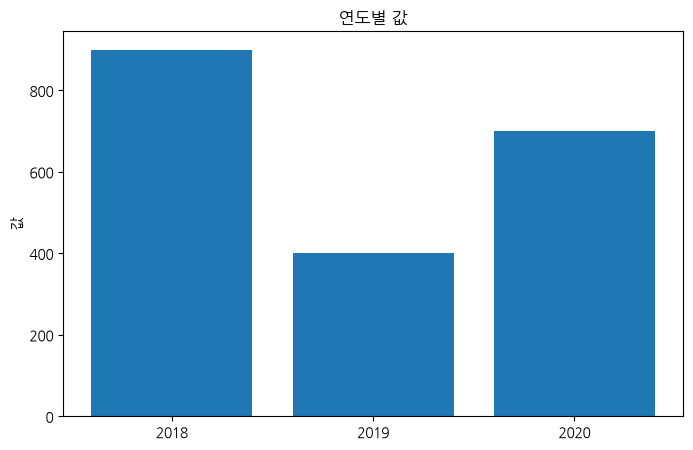

In [11]:
years = ['2018', '2019', '2020']
values = [900, 400, 700]

plt.bar(years, values)
plt.title("연도별 값")
plt.ylabel("값")
plt.show()

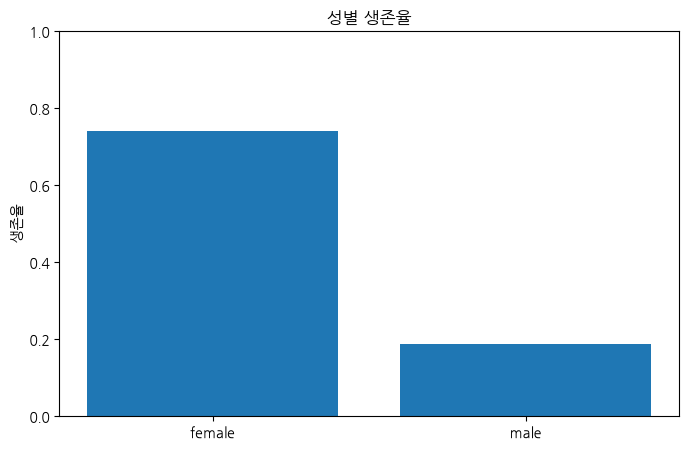

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [12]:
rate = df.groupby("Sex")["Survived"].mean()

plt.bar(rate.index, rate.values)
plt.title("성별 생존율")
plt.ylabel("생존율")
plt.ylim(0, 1)      # 비율이므로 0~1로 고정
plt.show()

print(rate)

### Box plot
데이터의 분포, 중앙값, 이상치를 한눈에 파악할 때 사용

### 박스플롯 읽는 법

- 박스 **아래선** = 25% 지점(Q1)
- 박스 안 **가로선** = 50% 지점 = **중앙값**
- 박스 **위선** = 75% 지점(Q3)
- 박스 **높이** = IQR (Q3 - Q1). 가운데 50%가 들어있는 범위
- **수염**(위아래 선) = Q1 - 1.5×IQR ~ Q3 + 1.5×IQR 안에 있는 값의 끝
- 수염 **밖의 점** = **이상치(outlier)**

**02번 describe()에서 본 25% / 50% / 75%가 바로 이것이다.**
describe()는 숫자로, 박스플롯은 그림으로 같은 정보를 보여준다.

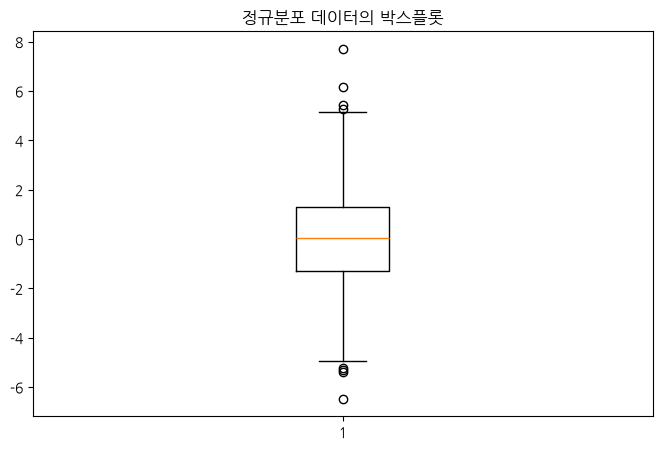

In [13]:
np.random.seed(42)
data_a = np.random.normal(0, 2.0, 1000)

plt.boxplot(data_a)
plt.title("정규분포 데이터의 박스플롯")
plt.show()

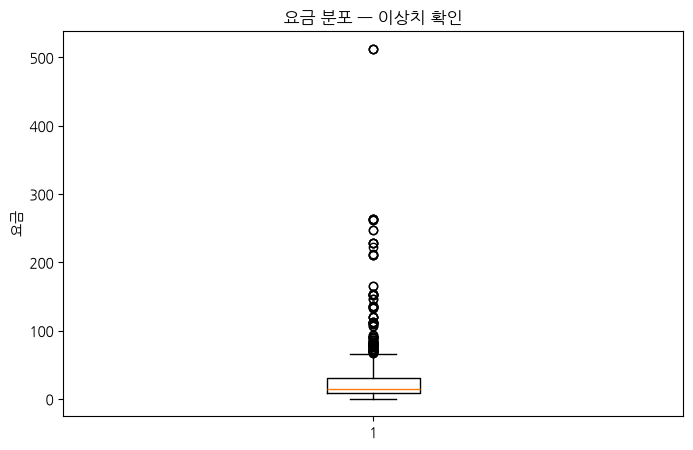

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [14]:
plt.boxplot(df["Fare"])
plt.title("요금 분포 — 이상치 확인")
plt.ylabel("요금")
plt.show()

print(df["Fare"].describe())

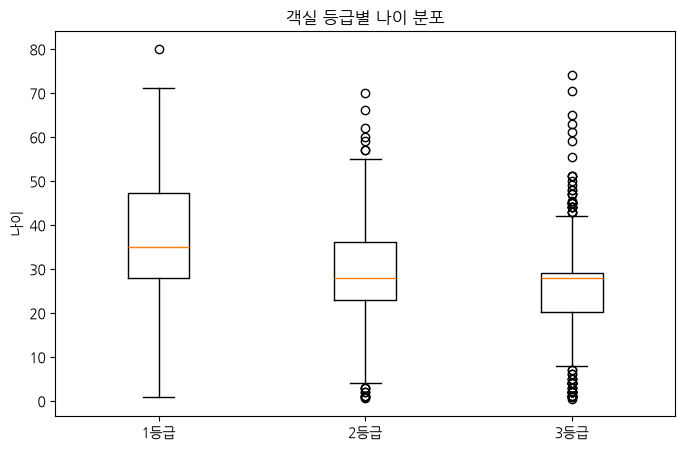

In [15]:
# 등급별 나이 분포를 나란히 비교
data = [df[df["Pclass"] == i]["Age"] for i in [1, 2, 3]]

plt.boxplot(data, tick_labels=["1등급", "2등급", "3등급"])
plt.title("객실 등급별 나이 분포")
plt.ylabel("나이")
plt.show()

### Pie plot
전체 데이터에서 각 항목이 차지하는 '비율'이나 '지분'이 얼마나 되는지 볼 때 사용

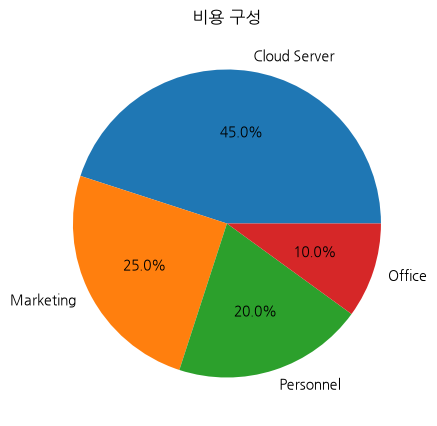

In [16]:
categories = ['Cloud Server', 'Marketing', 'Personnel', 'Office']
expenses = [450, 250, 200, 100]

plt.pie(expenses, labels=categories, autopct="%.1f%%")
plt.title("비용 구성")
plt.show()

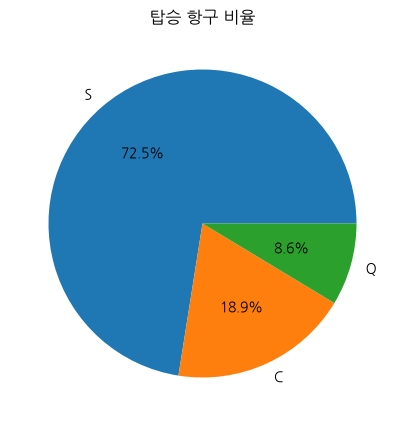

In [17]:
cnt = df["Embarked"].value_counts()

plt.pie(cnt.values, labels=cnt.index, autopct="%.1f%%")
plt.title("탑승 항구 비율")
plt.show()

## 그 외

### subplot
subplot(row, column, index): 여러 그래프를 한 그림에 나눠 그리기

**subplot(131) = subplot(1, 3, 1)**
→ 1행 3열로 나눈 공간의 **1번째 칸**
→ 위치 번호는 왼쪽 위부터 **1**로 시작한다 (0이 아니다)

호출할 때마다 "지금 그릴 칸"이 바뀐다. 지나간 칸으로는 돌아갈 수 없다.

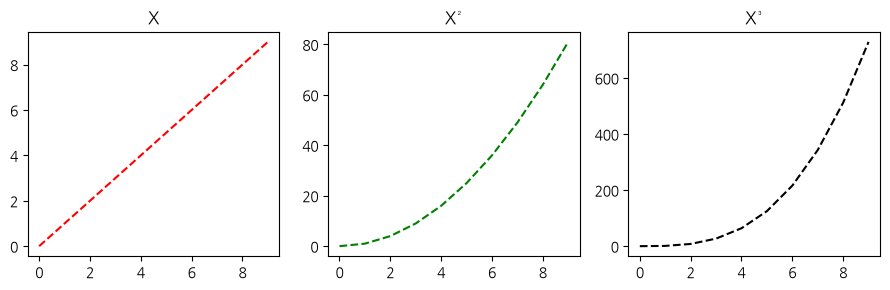

In [18]:
plt.figure(figsize=(9, 3))

plt.subplot(131); plt.plot(X, X,    "r--"); plt.title("X")
plt.subplot(132); plt.plot(X, X**2, "g--"); plt.title("X²")
plt.subplot(133); plt.plot(X, X**3, "k--"); plt.title("X³")

plt.tight_layout()   # 그래프끼리 글자가 겹치는 걸 막는다
plt.show()           # 없으면 객체 설명문이 같이 출력된다

### subplots
subplots(row, column, figsize): 칸들을 **변수로 받아서** 그리기

```python
fig, ax = plt.subplots(1, 3)
```
- `fig` = 페이지 전체 (**Figure**)
- `ax`  = 각 칸 (**Axes**)의 배열

| | 방식 | 차이 |
|---|---|---|
| plt.subplot(131) | 칸을 하나씩 "현재 칸"으로 지정 | 지나간 칸으로 **되돌아갈 수 없다** |
| plt.subplots(1,3) | ax 변수로 각 칸을 받아둔다 | ax[0]을 나중에 **언제든 다시 수정 가능** |

**맨 위에 정리한 Figure / Axes 개념이 코드로 드러나는 곳이 여기다.**
실무에서는 subplots를 쓴다.

**주의: ax를 쓸 때는 함수 이름 앞에 set_ 이 붙는다.**
plt.title() → ax.set_title()

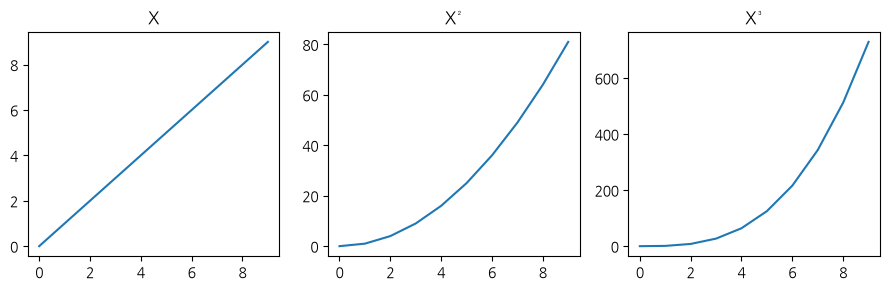

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].plot(X, X);    ax[0].set_title("X")
ax[1].plot(X, X**2); ax[1].set_title("X²")
ax[2].plot(X, X**3); ax[2].set_title("X³")

plt.tight_layout()
plt.show()

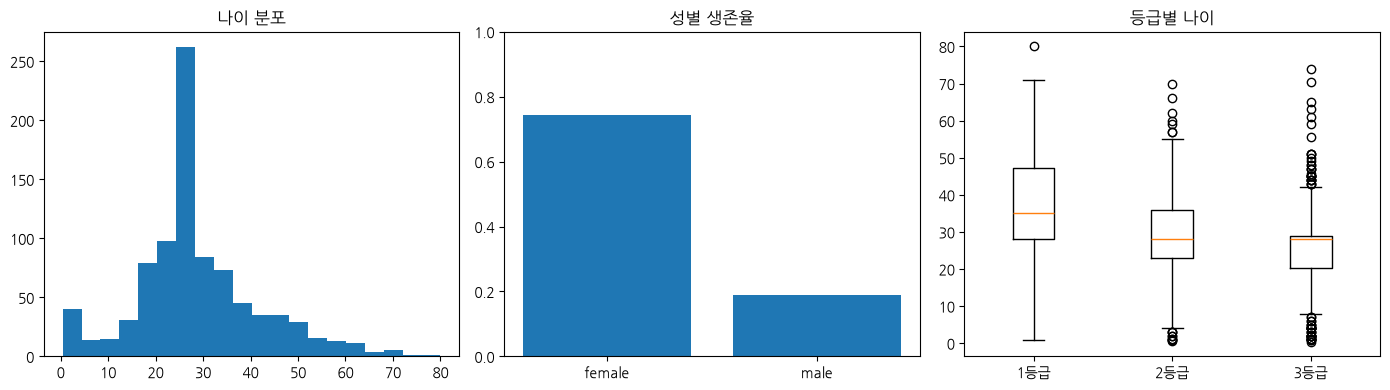

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].hist(df["Age"], bins=20)
ax[0].set_title("나이 분포")

rate = df.groupby("Sex")["Survived"].mean()
ax[1].bar(rate.index, rate.values)
ax[1].set_title("성별 생존율")
ax[1].set_ylim(0, 1)

ax[2].boxplot([df[df["Pclass"]==i]["Age"] for i in [1,2,3]],
              tick_labels=["1등급","2등급","3등급"])
ax[2].set_title("등급별 나이")

plt.tight_layout()
plt.show()

### savefig
savefig('파일명'): 그래프를 이미지 파일로 저장

**반드시 plt.show() 앞에서 호출해야 한다.**
show()는 그림을 화면에 띄우고 그 figure를 **비운다.**
show() 뒤에 savefig를 쓰면 빈 figure를 저장해서 **하얀 빈 이미지**가 나온다.

- dpi=150 → 해상도. 기본값(100)이면 발표자료에 넣기엔 흐리다
- bbox_inches="tight" → 잘린 축 이름까지 포함해서 저장

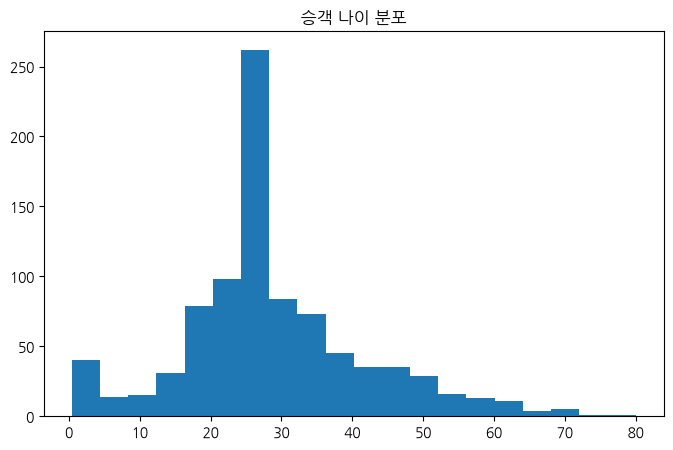

In [21]:
plt.hist(df["Age"], bins=20)
plt.title("승객 나이 분포")

plt.savefig("age_hist.png", dpi=150, bbox_inches="tight")   # show 앞에서
plt.show()

---
## 이번에 알게 된 것

1. **Figure / Axes 구조** — subplots를 쓰면 ax 변수로 각 칸을 들고 있어서
   나중에 수정할 수 있다. plt.subplot()은 못 한다.
2. **ax를 쓸 때는 set_ 이 붙는다** — plt.title() vs ax.set_title()
3. **bins는 내가 정하는 값이다** — 같은 데이터도 bins에 따라 해석이 달라진다
4. **savefig는 show()보다 먼저** — 아니면 빈 이미지가 저장된다
5. **시각화는 전처리 검증 수단이다** — 나이 히스토그램의 28세 막대가
   결측치를 중앙값으로 채운 흔적을 그대로 드러냈다